# Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import math

# Carregamento dos dados

In [ ]:
# Carregamento dos dados
from src.data.load_data import load_train_data
train = load_train_data()

# Diagnóstico do dataset

In [ ]:
def diagnostico_dataset(df):

    print("Dimensão do dataset:")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}\n")

    print("Tipos de dados:")
    print(df.dtypes, "\n")

    print("Valores nulos:")
    print(df.isnull().sum(), "\n")

    print("Valores negativos nas colunas numéricas:")

    colunas_numericas = df.select_dtypes(include='number').columns

    for coluna in colunas_numericas:
        negativos = (df[coluna] < 0).sum()
        print(f"{coluna}: {negativos}")

In [ ]:
diagnostico_dataset(train)

Dimensão do dataset:
Linhas: 5000
Colunas: 23

Tipos de dados:
Unnamed: 0                 int64
genero                    object
idoso                    float64
parceiro                  object
dependentes               object
tempoDeServico           float64
ServicoTelefone           object
MultiLinhas               object
ServicoInternet           object
ServicoSegurancaCyber     object
ServicoBackup             object
SeguroDispositivos        object
ServicoSuporteTecnico     object
StreamingTV               object
StreamingFilmes           object
Contrato                  object
BillingDigital            object
MetodoPagamento           object
FaturaMensal             float64
FaturaTotal               object
NumTickets               float64
NumTicketsTecnico        float64
Churn                    float64
dtype: object 

Valores nulos:
Unnamed: 0                 0
genero                   241
idoso                    265
parceiro                 238
dependentes              234
te

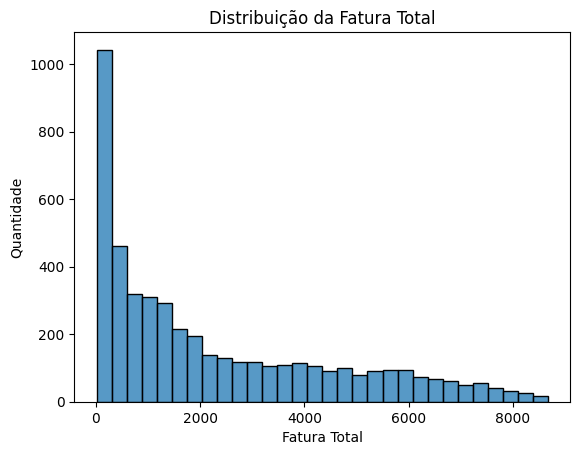

In [ ]:
fatura_total = pd.to_numeric(train['FaturaTotal'], errors='coerce')

sns.histplot(fatura_total, bins=30)
plt.title('Distribuição da Fatura Total')
plt.xlabel('Fatura Total')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
def multiplos_countplots_4(df, colunas, titulos, ncols=2):

    nrows = math.ceil(len(colunas) / ncols)

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(6*ncols, 4*nrows),
        constrained_layout=True
    )

    axs = axs.flatten()

    for i, coluna in enumerate(colunas):

        contagem = df[coluna].value_counts()
        ax = axs[i]

        sns.countplot(
            y=df[coluna],
            order=contagem.index,
            ax=ax
        )

        for j, count in enumerate(contagem):
            ax.text(count, j, str(count), ha='left', va='center')

        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_ylabel('')
        ax.set_xlabel('Quantidade')
        ax.set_title(titulos[i])

    # remove eixos vazios
    for j in range(len(colunas), len(axs)):
        fig.delaxes(axs[j])

    plt.show()

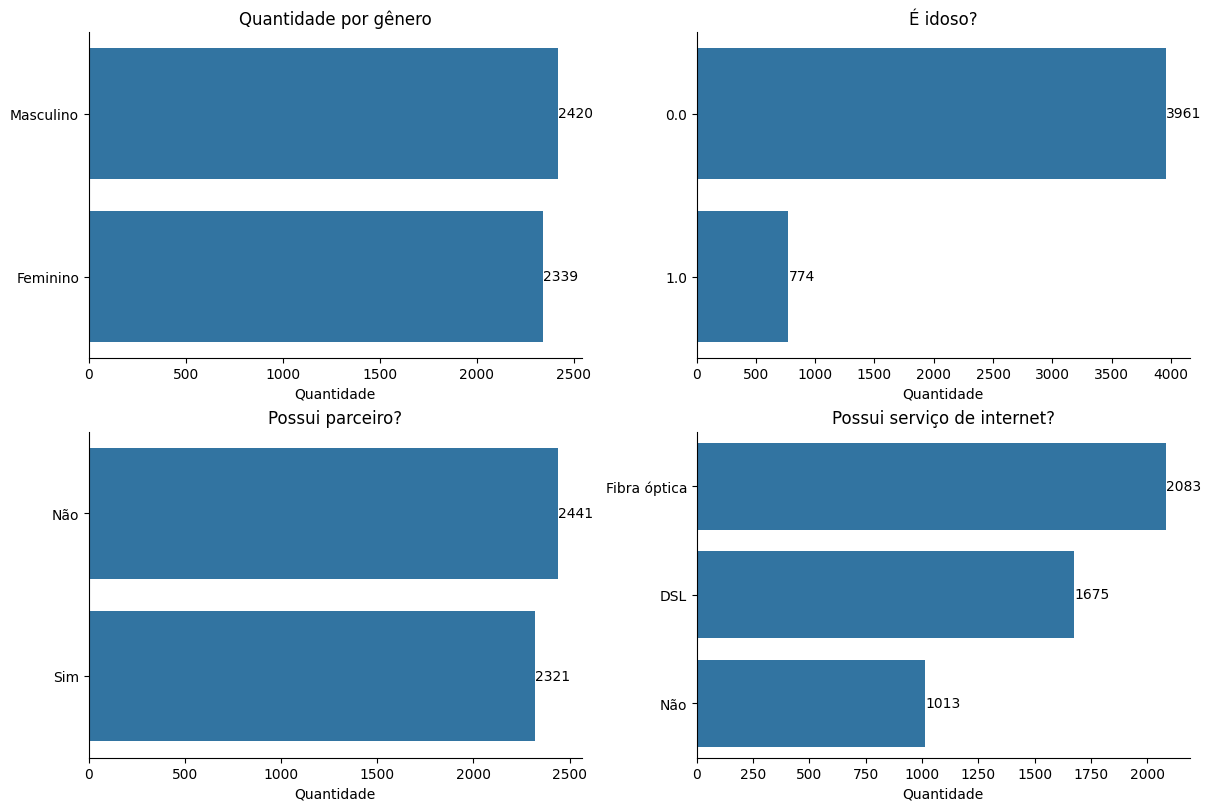

In [ ]:
colunas = [
    'genero',
    'idoso',
    'parceiro',
    'ServicoInternet'
]

titulos = [
    'Quantidade por gênero',
    'É idoso?',
    'Possui parceiro?',
    'Possui serviço de internet?'
]

multiplos_countplots_4(train, colunas, titulos, ncols=2)

In [ ]:
def multiplos_countplots_6(df, colunas, ncols=3):

    nrows = math.ceil(len(colunas) / ncols)

    fig, axs = plt.subplots(
        nrows,
        ncols,
        figsize=(6*ncols, 4*nrows),
        constrained_layout=True
    )

    axs = axs.flatten()

    for i, coluna in enumerate(colunas):

        contagem = df[coluna].value_counts()
        ax = axs[i]

        sns.barplot(
            x=contagem.values,
            y=contagem.index,
            ax=ax
        )

        for j, count in enumerate(contagem):
            ax.text(count, j, str(count), ha='left', va='center')

        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_ylabel('')
        ax.set_xlabel('Quantidade')
        ax.set_title(coluna)

    # Remove eixos vazios caso existam
    for j in range(len(colunas), len(axs)):
        fig.delaxes(axs[j])

    plt.show()

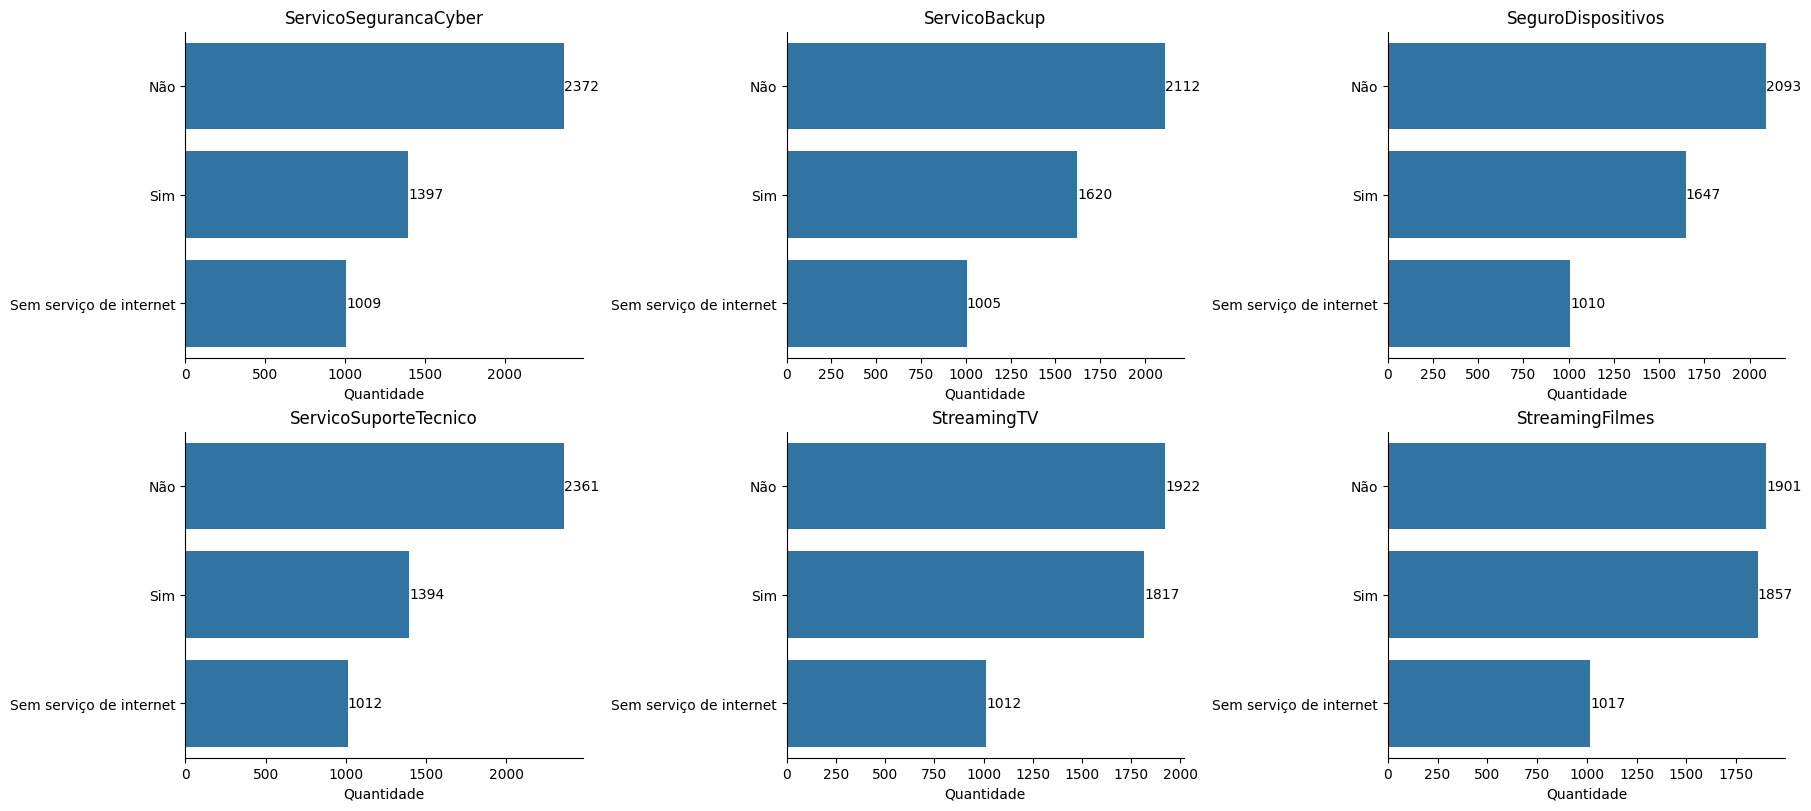

In [ ]:
colunas_servicos = [
    'ServicoSegurancaCyber',
    'ServicoBackup',
    'SeguroDispositivos',
    'ServicoSuporteTecnico',
    'StreamingTV',
    'StreamingFilmes'
]

multiplos_countplots_6(train, colunas_servicos)

In [ ]:
def plot_boxplots(df, colunas):

    for coluna, nome in colunas.items():

        fig = px.box(
            df,
            y=coluna,
            title=f'Boxplot de {nome}'
        )

        fig.update_layout(yaxis_title=nome)

        fig.show()

In [ ]:
colunas_boxplot = {
    'tempoDeServico': 'Tempo de Serviço',
    'FaturaMensal': 'Fatura Mensal'
}

plot_boxplots(train, colunas_boxplot)

# Distribuição do target

In [ ]:
categoricas = train.select_dtypes(include=['object', 'category']).columns
categoricas = [c for c in categoricas if c != 'FaturaMensal']

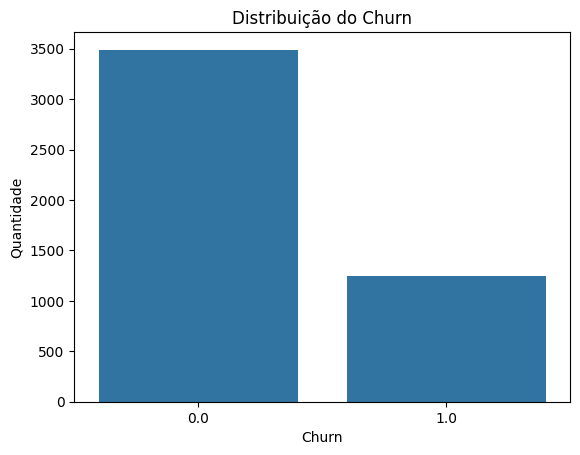

In [ ]:
sns.countplot(x=train['Churn'])

plt.title('Distribuição do Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade')

plt.show()

# Variáveis categóricas com relação ao churn

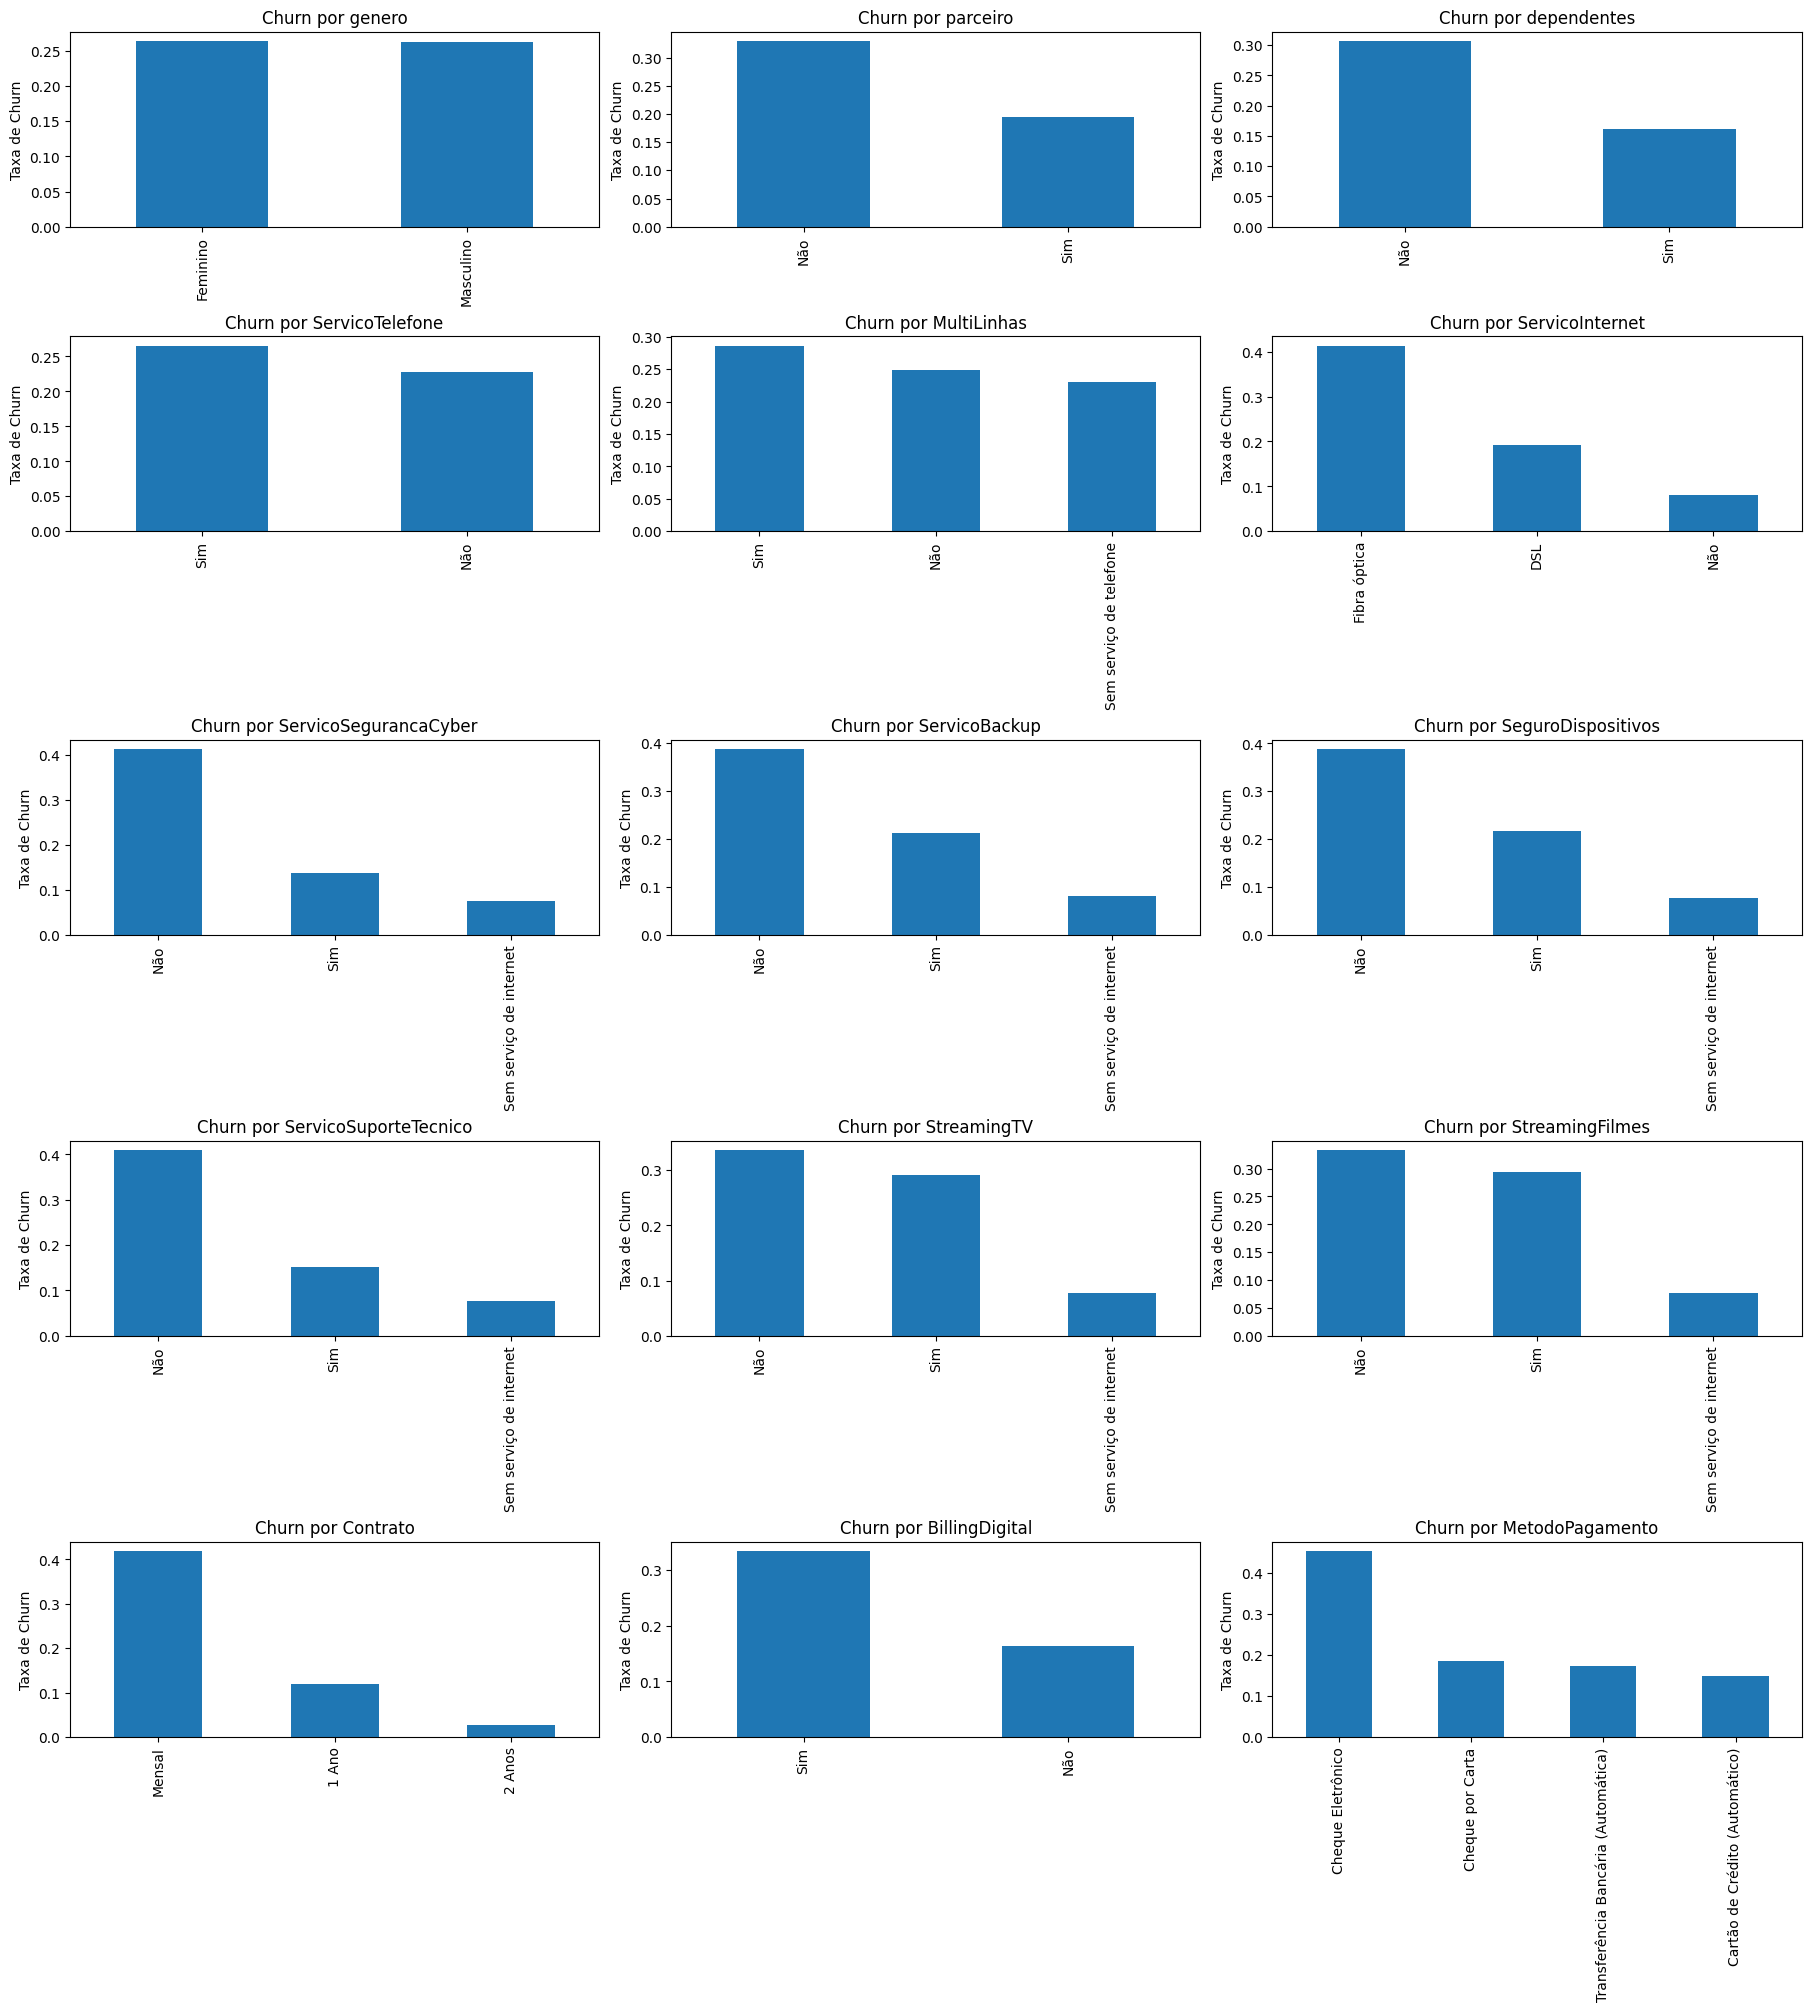

In [ ]:
categoricas = train.select_dtypes(include=['object', 'category']).columns
categoricas = [c for c in categoricas if c not in ['FaturaMensal', 'FaturaTotal']]

ncols = 3
nrows = math.ceil(len(categoricas) / ncols)

fig, axs = plt.subplots(
    nrows,
    ncols,
    figsize=(6*ncols, 4*nrows),
    constrained_layout=True
)

axs = axs.flatten()

for i, coluna in enumerate(categoricas):

    churn_rate = (
        train.groupby(coluna)['Churn']
        .mean()
        .sort_values(ascending=False)
    )

    ax = axs[i]

    churn_rate.plot(
        kind='bar',
        ax=ax
    )

    ax.set_title(f'Churn por {coluna}')
    ax.set_ylabel('Taxa de Churn')
    ax.set_xlabel('')

# remove eixos vazios
for j in range(len(categoricas), len(axs)):
    fig.delaxes(axs[j])

plt.show()

# Variáveis numéricas com relação ao churn

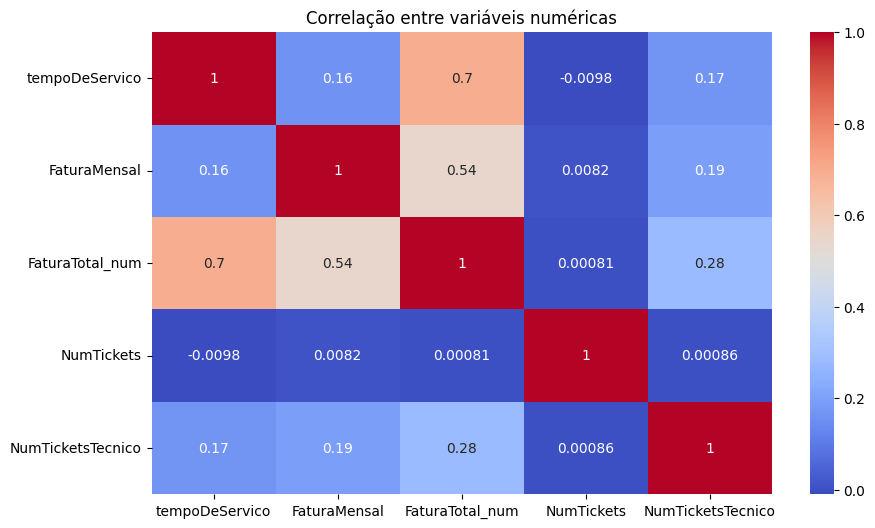

In [ ]:
# criar versão numérica temporária
train['FaturaTotal_num'] = pd.to_numeric(train['FaturaTotal'], errors='coerce')

numericas = [
    'tempoDeServico',
    'FaturaMensal',
    'FaturaTotal_num',
    'NumTickets',
    'NumTicketsTecnico'
]

plt.figure(figsize=(10,6))
sns.heatmap(train[numericas].corr(), annot=True, cmap='coolwarm')
plt.title('Correlação entre variáveis numéricas')
plt.show()

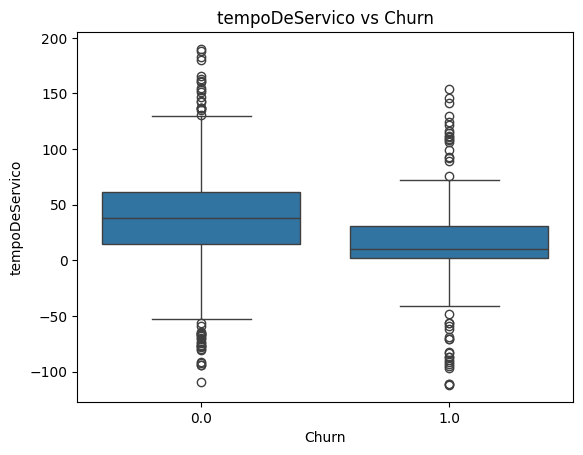

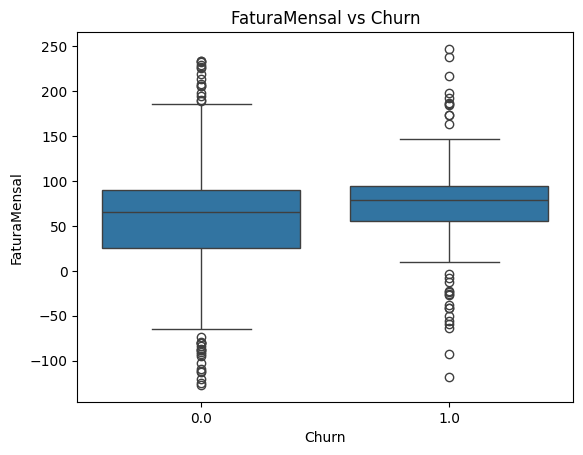

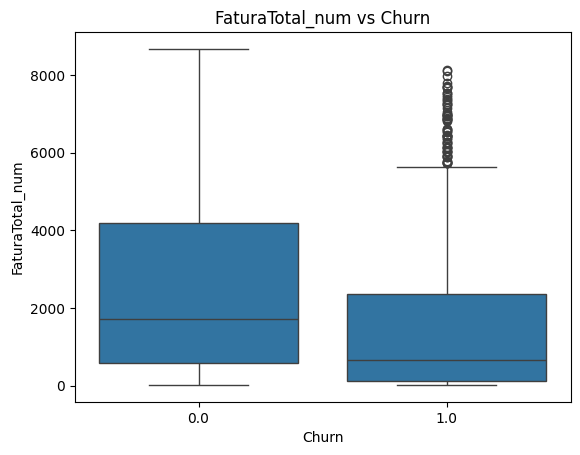

In [ ]:
numericas = ['tempoDeServico','FaturaMensal','FaturaTotal_num']

for col in numericas:

    sns.boxplot(
        x='Churn',
        y=col,
        data=train
    )

    plt.title(f'{col} vs Churn')
    plt.show()